In [1]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *

In [2]:
manifold_type = 'S1'; manifold = get_manifold(manifold_type)
num_modes = 2; tau2 = 0.05; sigma2 = .1
G = lambda n: multimodal_sampler(manifold_type, n, tau2, num_modes) 

### Runtime-performance of implementations

MC runs: 5, num_oracle_samples: 5000, num_test: 2000
---- Summary across MC runs (mean ± std) ----
  naive | runtime(s): 3.2655 ± 0.3581 | loss(mean): 0.0358817 ± 0.000999832


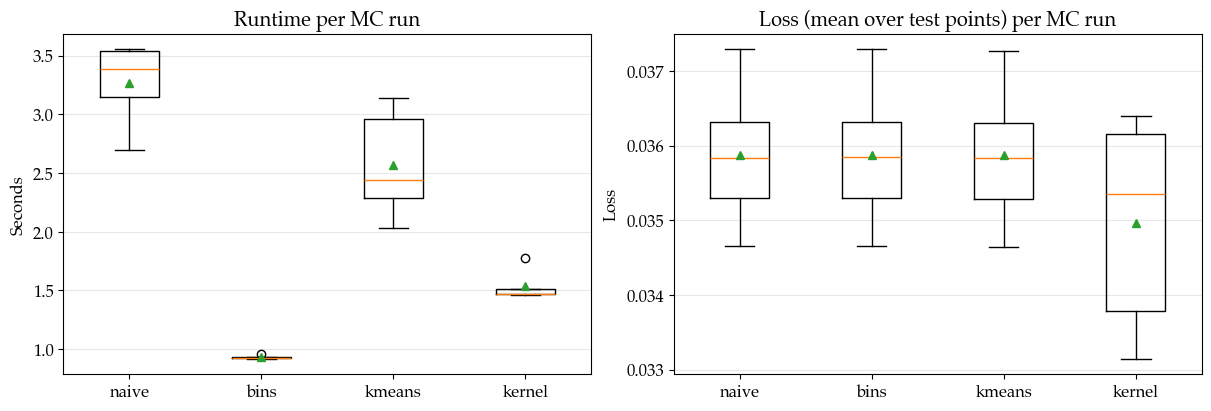

   bins | runtime(s): 0.9320 ± 0.0179 | loss(mean): 0.0358822 ± 0.000999954


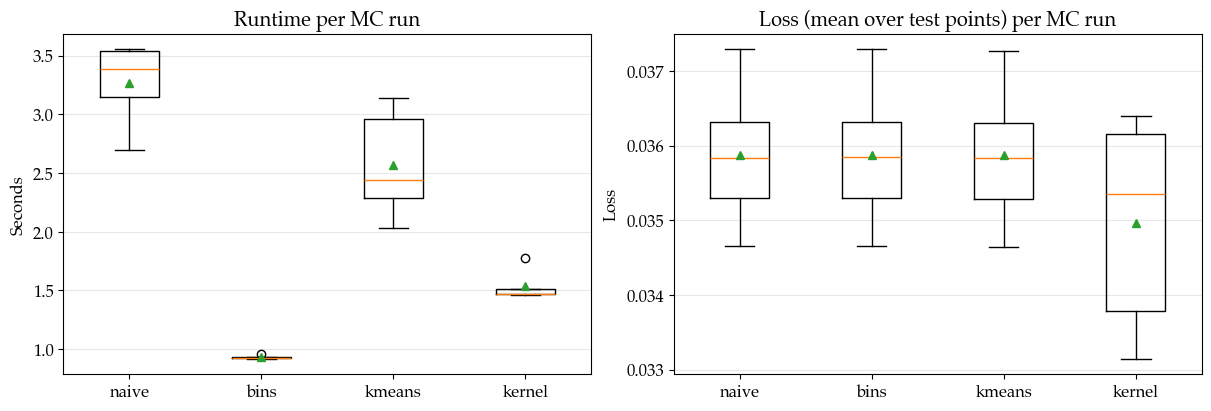

 kmeans | runtime(s): 2.5702 ± 0.4626 | loss(mean): 0.0358721 ± 0.000998556


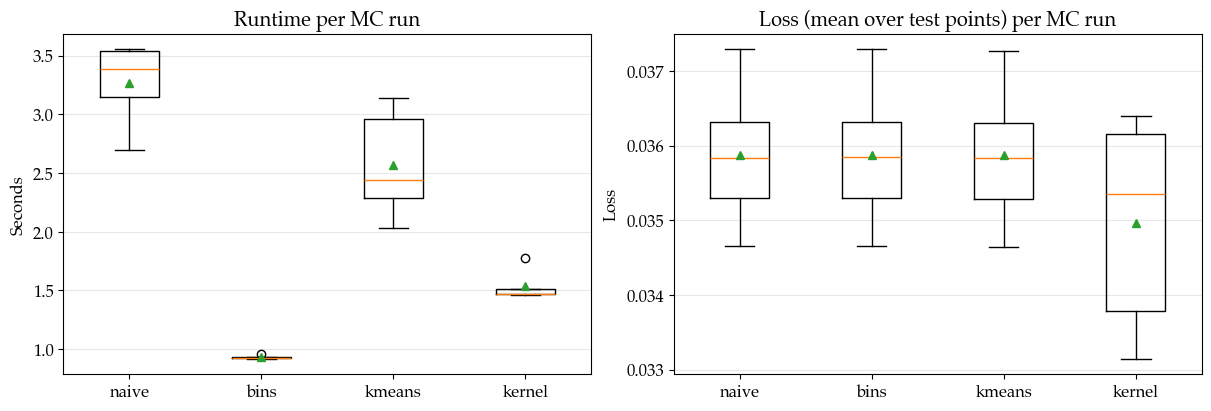

 kernel | runtime(s): 1.5389 ± 0.1353 | loss(mean): 0.0349678 ± 0.00144319


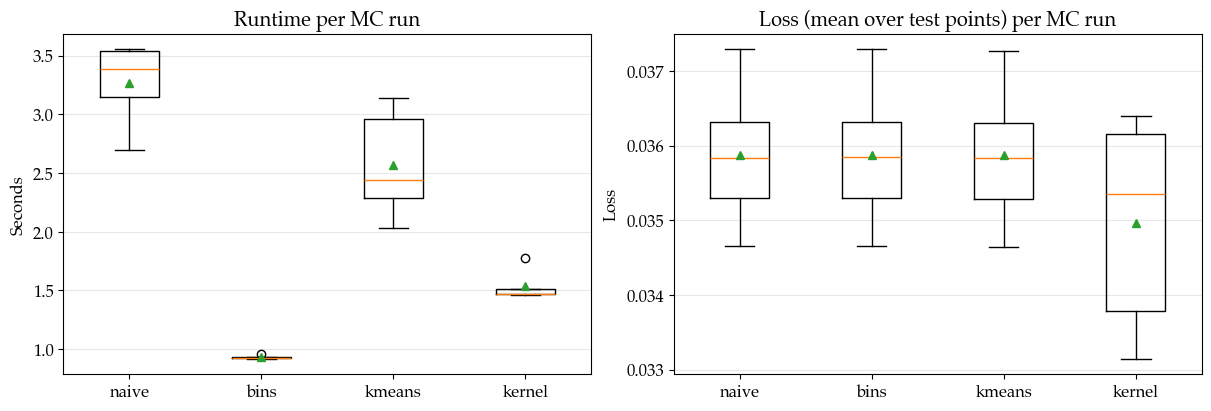

In [5]:
# --- Monte Carlo comparison: runtime & loss (mean/std) ---

import time
import numpy as np
from tqdm.auto import tqdm

# Settings
mc_runs = 5                 # number of Monte Carlo trials
num_oracle_samples = 5000   # training samples per trial
num_test = 2000              # test points per trial
n_bins = 1000

def _as_1d_loss(loss_out):
    arr = np.asarray(loss_out)
    return arr.reshape(1) if arr.ndim == 0 else arr.reshape(-1)

def _time_call(fn, *args, **kwargs):
    t0 = time.perf_counter()
    out = fn(*args, **kwargs)
    return out, (time.perf_counter() - t0)

methods = {
    "naive":  lambda Theta_train, X_test: oracle_denoiser__naive(manifold_type, Theta_train, sigma2, X_test),
    "bins": lambda Theta_train, X_test: oracle_denoiser(manifold_type, Theta_train, sigma2, X_test, n_bins),
    "kmeans": lambda Theta_train, X_test: oracle_denoiser__kmeans(manifold_type, Theta_train, sigma2, X_test, n_bins),
    "kernel": lambda Theta_train, X_test: oracle_denoiser__kernel(manifold_type, Theta_train, sigma2, X_test),
}

results = {
    name: {"runtime_s": [], "loss_mean": [], "loss_std": []}
    for name in methods
}

mc_pbar = tqdm(range(mc_runs), desc="MC runs", unit="run")
for r in mc_pbar:
    Theta_train = G(num_oracle_samples)
    Theta_test = G(num_test)
    X_test = manifold.random_riemannian_normal(Theta_test, 1.0 / sigma2, num_test)

    for name, builder in tqdm(list(methods.items()), desc=f"methods (run {r+1}/{mc_runs})", leave=False, unit="method"):
        delta, dt = _time_call(builder, Theta_train, X_test)

        loss_out = sq_loss(manifold, delta, Theta_test)
        loss_vec = _as_1d_loss(loss_out)

        results[name]["runtime_s"].append(dt)
        results[name]["loss_mean"].append(float(loss_vec.mean()))
        results[name]["loss_std"].append(float(loss_vec.std(ddof=1)) if loss_vec.size > 1 else 0.0)

    # lightweight live status: current run mean losses
    live = " | ".join(f"{n}:{results[n]['loss_mean'][-1]:.3g}" for n in methods)
    mc_pbar.set_postfix_str(live)

def _summ(x):
    x = np.asarray(x, dtype=float)
    return float(x.mean()), (float(x.std(ddof=1)) if x.size > 1 else 0.0)

print(f"MC runs: {mc_runs}, num_oracle_samples: {num_oracle_samples}, num_test: {num_test}")
print("---- Summary across MC runs (mean ± std) ----")
for name in methods:
    rt_m, rt_s = _summ(results[name]["runtime_s"])
    lm_m, lm_s = _summ(results[name]["loss_mean"])
    print(f"{name:>7s} | runtime(s): {rt_m:.4f} ± {rt_s:.4f} | loss(mean): {lm_m:.6g} ± {lm_s:.6g}")

# --- Side-by-side boxplots: runtime and loss across MC runs ---

fig, axs = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

method_names = list(methods.keys())

# Runtime boxplot
axs[0].boxplot(
    [np.asarray(results[m]["runtime_s"], dtype=float) for m in method_names],
    tick_labels=method_names,
    showmeans=True,
)
axs[0].set_title("Runtime per MC run")
axs[0].set_ylabel("Seconds")
axs[0].grid(axis="y", alpha=0.3)

# Loss(mean) boxplot
axs[1].boxplot(
    [np.asarray(results[m]["loss_mean"], dtype=float) for m in method_names],
    tick_labels=method_names,
    showmeans=True,
)
axs[1].set_title("Loss (mean over test points) per MC run")
axs[1].set_ylabel("Loss")
axs[1].grid(axis="y", alpha=0.3)

plt.show()

### Error

In [4]:
num_oracle_samples_ls = np.array([1e2,1e3,1e4], dtype=int)
NMC = 10

num_test_samples = 1000

results = {k: np.zeros(NMC) for k in num_oracle_samples_ls}

Theta = G(num_test_samples)
x_to_denoise = manifold.random_riemannian_normal(Theta, 1/sigma2, num_test_samples)

pbar_outer = tqdm(num_oracle_samples_ls, desc="oracle samples", unit="n", position=0, leave=True)
for num_oracle_samples in pbar_outer:
    pbar_inner = tqdm(range(NMC), desc=f"MC (n={num_oracle_samples})", unit="run", position=1, leave=True)
    for mc in pbar_inner:
        oracle_delta_T = oracle_denoiser(
            manifold_type, num_oracle_samples, sigma2, x_to_denoise, G, n_bins=num_oracle_samples//10
        )
        results[num_oracle_samples][mc] = sq_loss(manifold, oracle_delta_T, Theta) 
        pbar_inner.set_postfix(mean=float(results[num_oracle_samples][mc].mean()))


oracle samples:   0%|          | 0/3 [00:00<?, ?n/s]

oracle samples: 100%|██████████| 3/3 [00:29<00:00,  9.74s/n]


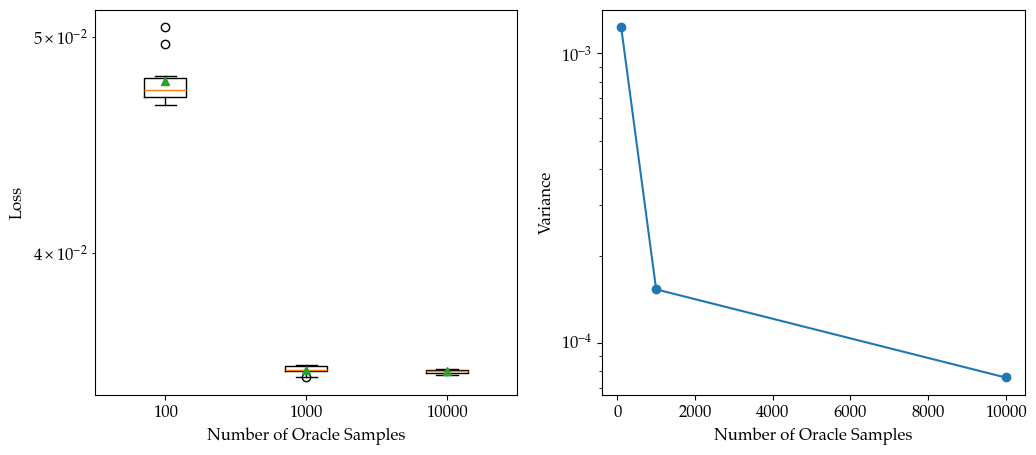

In [5]:
num_oracle_samples_to_loss = {num_oracle_samples: results[num_oracle_samples] for num_oracle_samples in num_oracle_samples_ls}

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].boxplot(
    [num_oracle_samples_to_loss[k].flatten() for k in num_oracle_samples_ls],
    tick_labels=[str(k) for k in num_oracle_samples_ls],
    showmeans=True,
)
axs[0].set_xlabel("Number of Oracle Samples")
axs[0].set_ylabel("Loss")
axs[0].grid(axis="y", alpha=0.3)
axs[0].set_yscale('log')

axs[1].plot(num_oracle_samples_ls, [num_oracle_samples_to_loss[k].std() for k in num_oracle_samples_ls], marker='o')
axs[1].set_yscale('log')
axs[1].set_yticks([1e-4,1e-3,])
axs[1].set_ylabel("Variance")
axs[1].set_xlabel("Number of Oracle Samples")



plt.show()

### Displacement

In [6]:
G = lambda n: uniform_sampler(manifold_type, n) 

In [7]:
num_oracle_samples_ls = np.array([1e2,1e3,1e4], dtype=int)

NMC = 10

num_test_samples = 1000

results = {k: np.zeros((NMC, num_test_samples,manifold.dim + 1)) for k in num_oracle_samples_ls}
Theta = G(num_test_samples)
x_to_denoise = manifold.random_riemannian_normal(Theta, 1/sigma2, num_test_samples)

pbar_outer = tqdm(num_oracle_samples_ls, desc="oracle samples", unit="n", position=0, leave=True)
for num_oracle_samples in pbar_outer:
    pbar_inner = tqdm(range(NMC), desc=f"MC (n={num_oracle_samples})", unit="run", position=1, leave=True)
    for mc in pbar_inner:
        oracle_delta_T = oracle_denoiser(
            manifold_type, num_oracle_samples, sigma2, x_to_denoise, G, n_bins=num_oracle_samples//5
        )
        results[num_oracle_samples][mc] = oracle_delta_T
        pbar_inner.set_postfix(mean=float(results[num_oracle_samples][mc].mean()))


oracle samples: 100%|██████████| 3/3 [00:30<00:00, 10.08s/n]


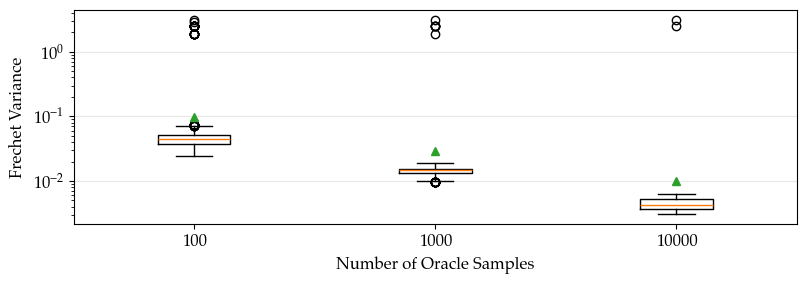

In [8]:
intr_results = {num_oracle_samples: manifold.extrinsic_to_angle(results[num_oracle_samples]) for num_oracle_samples in num_oracle_samples_ls}
num_oracle_samples_to_std = {num_oracle_samples: intr_results[num_oracle_samples].std(axis=0) for num_oracle_samples in num_oracle_samples_ls}


plt.figure(figsize=(8, 3))
plt.boxplot(
    [num_oracle_samples_to_std[k].flatten() for k in num_oracle_samples_ls],
    tick_labels=[str(k) for k in num_oracle_samples_ls],
    showmeans=True,
)
plt.xlabel("Number of Oracle Samples")
plt.ylabel("Frechet Variance")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.yscale('log')
plt.show()

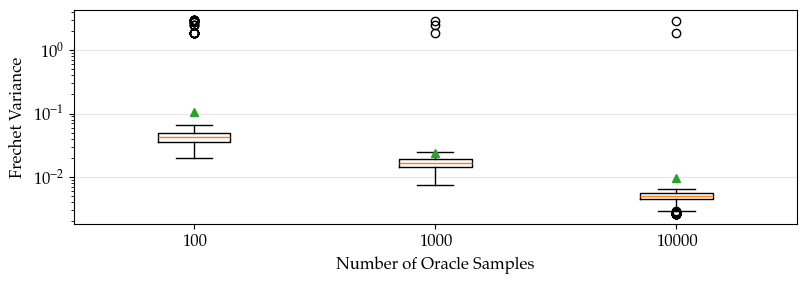

In [ ]:
intr_results = {num_oracle_samples: manifold.extrinsic_to_angle(results[num_oracle_samples]) for num_oracle_samples in num_oracle_samples_ls}
num_oracle_samples_to_std = {num_oracle_samples: intr_results[num_oracle_samples].std(axis=0) for num_oracle_samples in num_oracle_samples_ls}


plt.figure(figsize=(8, 3))
plt.boxplot(
    [num_oracle_samples_to_std[k].flatten() for k in num_oracle_samples_ls],
    tick_labels=[str(k) for k in num_oracle_samples_ls],
    showmeans=True,
)
plt.xlabel("Number of Oracle Samples")
plt.ylabel("Frechet Variance")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.yscale('log')
plt.show()